In [1]:
import subprocess
subprocess.run(['pip', 'install', 'torch', 'torchvision', '--index-url', 
                'https://download.pytorch.org/whl/cu118', '-q'])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 45.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 37.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 57.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 27.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 13.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 8.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 MB 11.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 905.2/905.2 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.7.1+cu118 which is incompatible.


CompletedProcess(args=['pip', 'install', 'torch', 'torchvision', '--index-url', 'https://download.pytorch.org/whl/cu118', '-q'], returncode=0)

In [2]:

import torch
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(99)
np.random.seed(99)


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cuda


In [4]:
def soliton(x, t, c, x0):
    """Positive-convention single soliton: peak amplitude c/2, travels at speed c."""
    arg = (torch.sqrt(torch.tensor(float(c))) / 2.0) * (x - c * t - x0)
    return (c / 2.0) / torch.cosh(arg) ** 2


def make_config(N, d=10.0, T=5.0):
    """
    Build N-soliton configuration.

    Speed rule  : c_k = 1.5 + 0.5*(N-1-k)  -> slowest=1.5, step=0.5, fastest rightmost
    Position rule: x0_k = ((N-1)/2 - k)*d  -> symmetric about x=0, separation d=10
    Domain      : derived from travel distance + buffer
    Returns: speeds (list), x0s (list), domain (x_left, x_right)
    """
    speeds = [1.5 + 0.5 * (N - 1 - k) for k in range(N)]
    x0s    = [((N - 1) / 2.0 - k) * d  for k in range(N)]
    c_max   = speeds[0]
    x_left  = x0s[-1] - 10.0
    x_right = x0s[0]  + c_max * T + 15.0
    return speeds, x0s, (x_left, x_right)


def n_soliton(x, t, speeds, x0s):
    """Superposition of N well-separated solitons (exact ansatz when profiles don't overlap)."""
    u = torch.zeros_like(x, dtype=torch.float32)
    for c, x0 in zip(speeds, x0s):
        u = u + soliton(x, t, float(c), float(x0))
    return u


# ── Sanity check: verify configs for all target N ──
print(f"{'N':>4} | {'speeds':^52} | {'x0s':^38} | {'domain':^18} | {'width':>6}")
print("-" * 130)
for N in [3, 4, 6, 9, 12]:   # all target N values (N=3 anchors to preliminary paper)
    sp, x0, dom = make_config(N)
    w = dom[1] - dom[0]
    print(f"{N:>4} | {str([round(c,1) for c in sp]):^52} | {str([round(x,1) for x in x0]):^38} | [{dom[0]:.0f},{dom[1]:.0f}] | {w:>6.0f}")
print("\nN=3: speeds [2.5,2.0,1.5], x0=[10,0,-10], domain ~[-20,40] — exact match to preliminary paper.")


   N |                        speeds                        |                  x0s                   |       domain       |  width
----------------------------------------------------------------------------------------------------------------------------------
   3 |                   [2.5, 2.0, 1.5]                    |           [10.0, 0.0, -10.0]           | [-20,38] |     58
   4 |                 [3.0, 2.5, 2.0, 1.5]                 |        [15.0, 5.0, -5.0, -15.0]        | [-25,45] |     70
   6 |            [4.0, 3.5, 3.0, 2.5, 2.0, 1.5]            | [25.0, 15.0, 5.0, -5.0, -15.0, -25.0]  | [-35,60] |     95
   9 |    [5.5, 5.0, 4.5, 4.0, 3.5, 3.0, 2.5, 2.0, 1.5]     | [40.0, 30.0, 20.0, 10.0, 0.0, -10.0, -20.0, -30.0, -40.0] | [-50,82] |    132
  12 | [7.0, 6.5, 6.0, 5.5, 5.0, 4.5, 4.0, 3.5, 3.0, 2.5, 2.0, 1.5] | [55.0, 45.0, 35.0, 25.0, 15.0, 5.0, -5.0, -15.0, -25.0, -35.0, -45.0, -55.0] | [-65,105] |    170

N=3: speeds [2.5,2.0,1.5], x0=[10,0,-10], domain ~[-20,40] — exact

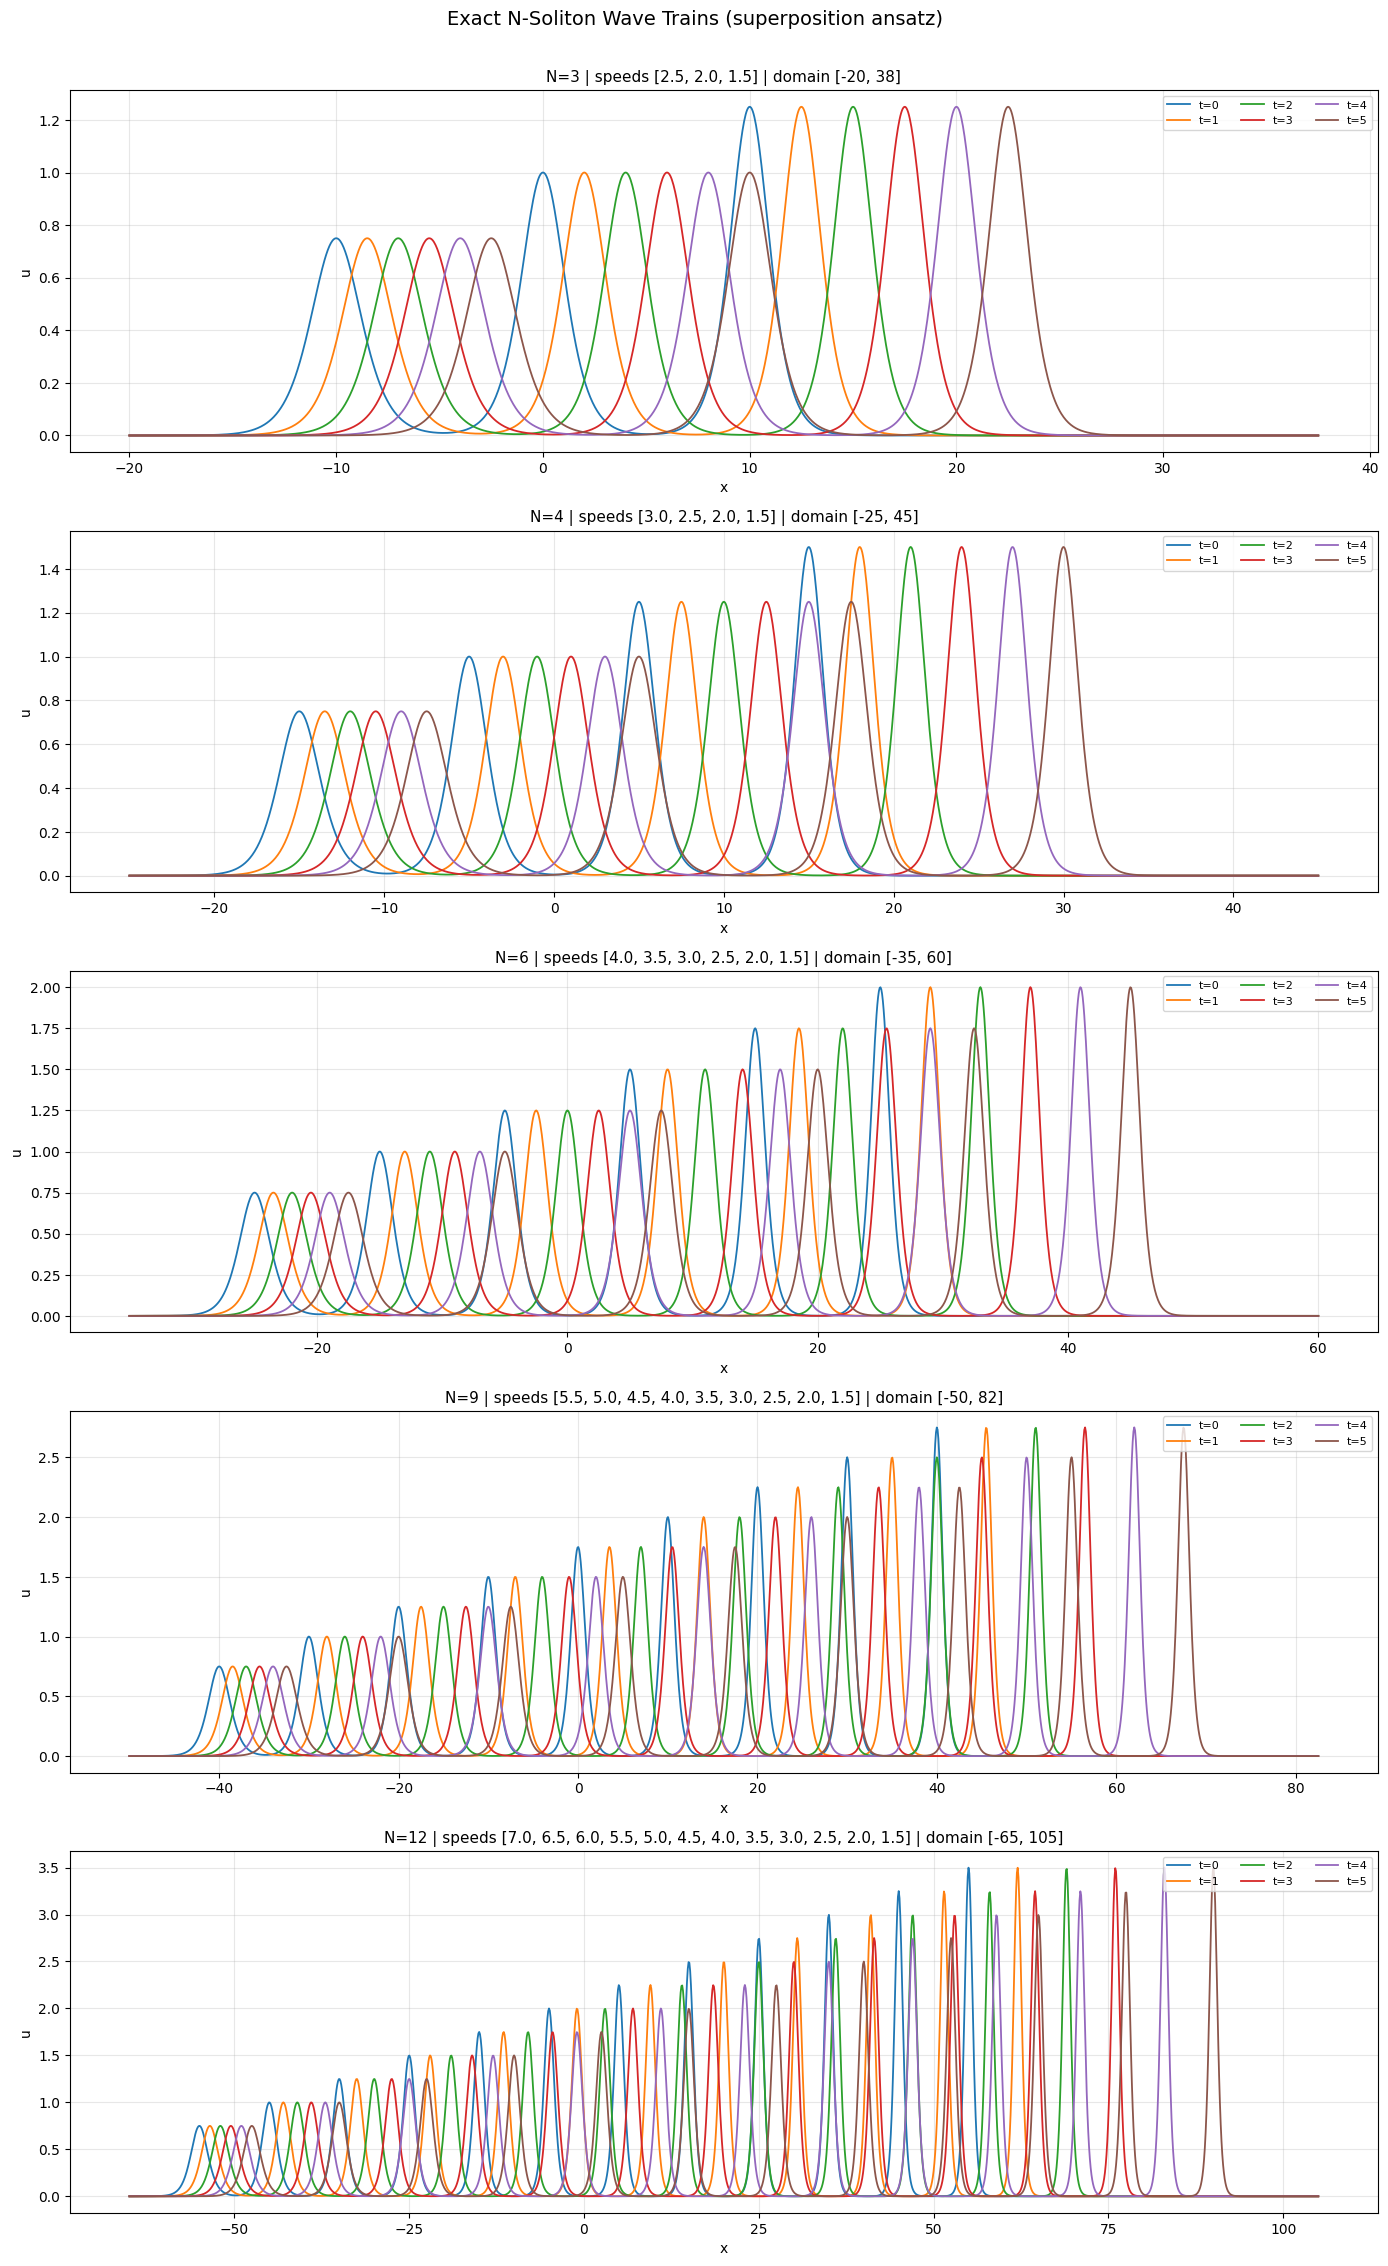

Saved: exact_wave_trains.png


In [5]:
N_LIST = [3, 4, 6, 9, 12]   # N=3 anchors to preliminary paper; 4,6,9,12 extend the study
T_END  = 5.0
t_plot = [0, 1, 2, 3, 4, 5]

fig, axes = plt.subplots(len(N_LIST), 1, figsize=(14, 4.5 * len(N_LIST)))

for row, N in enumerate(N_LIST):
    speeds, x0s, (xl, xr) = make_config(N, T=T_END)
    x = torch.linspace(xl, xr, 1500)
    ax = axes[row]
    for t_val in t_plot:
        t = torch.full_like(x, float(t_val))
        u = n_soliton(x, t, speeds, x0s)
        ax.plot(x.numpy(), u.numpy(), label=f't={t_val}', linewidth=1.3)
    ax.set_title(f'N={N} | speeds {[round(c,1) for c in speeds]} | domain [{xl:.0f}, {xr:.0f}]', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('u')
    ax.legend(fontsize=8, loc='upper right', ncol=3)
    ax.grid(True, alpha=0.3)

plt.suptitle('Exact N-Soliton Wave Trains (superposition ansatz)', fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig('exact_wave_trains.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exact_wave_trains.png')


In [6]:
class PINN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        layers = [torch.nn.Linear(2, 50)] + [torch.nn.Linear(50, 50) for _ in range(5)] + [torch.nn.Linear(50, 1)]
        self.layers = torch.nn.ModuleList(layers)
        for layer in self.layers:
            torch.nn.init.xavier_normal_(layer.weight)
            torch.nn.init.zeros_(layer.bias)

    def forward(self, x, t):
        z = torch.cat([x, t], dim=1)
        for layer in self.layers[:-1]:
            z = torch.tanh(layer(z))
        return self.layers[-1](z)


# Quick sanity check
_m = PINN()
_x = torch.rand(3, 1); _t = torch.rand(3, 1)
print('Output shape:', _m(_x, _t).shape)   # expect (3, 1)
total_params = sum(p.numel() for p in _m.parameters())
print(f'Total parameters: {total_params:,}   (same as baseline)')


Output shape: torch.Size([3, 1])
Total parameters: 12,951   (same as baseline)


In [7]:
def derivatives(model, x, t):
    u     = model(x, t)
    u_x   = torch.autograd.grad(u,    x,  grad_outputs=torch.ones_like(u),   create_graph=True)[0]
    u_t   = torch.autograd.grad(u,    t,  grad_outputs=torch.ones_like(u),   create_graph=True)[0]
    u_xx  = torch.autograd.grad(u_x,  x,  grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    u_xxx = torch.autograd.grad(u_xx, x,  grad_outputs=torch.ones_like(u_xx),create_graph=True)[0]
    return u, u_t, u_x, u_xxx


def pde_loss(model, x, t):
    """Positive KdV: u_t + 6u u_x + u_xxx = 0"""
    u, u_t, u_x, u_xxx = derivatives(model, x, t)
    res = u_t + 6.0 * u * u_x + u_xxx
    return torch.mean(res ** 2)


def ic_loss(model, x_ic, t_ic, exact_fn):
    u_pred  = model(x_ic, t_ic)
    u_exact = exact_fn(x_ic.squeeze(), t_ic.squeeze()).unsqueeze(1)
    return torch.mean((u_pred - u_exact) ** 2)


def bc_loss(model, x_bc, t_bc):
    """Dirichlet zero at domain boundaries (solitons decay exponentially)."""
    return torch.mean(model(x_bc, t_bc) ** 2)


def data_loss(model, x_d, t_d, u_d):
    return torch.mean((model(x_d, t_d) - u_d) ** 2)


def total_loss(model, batch, exact_fn):
    x_pde, t_pde, x_ic, t_ic, x_bc, t_bc, x_d, t_d, u_d = batch
    lp = pde_loss (model, x_pde, t_pde)
    li = ic_loss  (model, x_ic,  t_ic, exact_fn)
    lb = bc_loss  (model, x_bc,  t_bc)
    ld = data_loss(model, x_d,   t_d,  u_d)
    return lp + li + lb + ld, lp, li, lb, ld


In [8]:
def build_data(speeds, x0s, domain, T, device):
    """
    Build all training tensors. Collocation density held constant:
      n_pde  = 20000 * (width/60)   -- scales with domain area
      n_data = 400   * (width/60)   -- scales with domain area
      n_ic   >= 500  (at least baseline count)
      n_bc   = 100   (per edge, fixed)
    """
    xl, xr = domain
    width  = xr - xl
    scale  = width / 60.0          # baseline 3-soliton domain was ~60 units

    n_pde  = int(20000 * scale)
    n_data = int(400   * scale)
    n_ic   = max(500,  int(500 * scale))
    n_bc   = 100

    # PDE collocation — random in (x,t)
    x_pde = (xl + width * torch.rand(n_pde, 1)).to(device).requires_grad_(True)
    t_pde = (T  *         torch.rand(n_pde, 1)).to(device).requires_grad_(True)

    # Scattered synthetic measurements
    x_d = (xl + width * torch.rand(n_data, 1)).to(device)
    t_d = (T  *         torch.rand(n_data, 1)).to(device)
    efn = lambda x, t: n_soliton(x, t, speeds, x0s)
    u_d = efn(x_d.squeeze(), t_d.squeeze()).unsqueeze(1).to(device)

    # Initial condition t=0 (uniform in x)
    x_ic = torch.linspace(xl, xr, n_ic).view(-1, 1).to(device).requires_grad_(True)
    t_ic = torch.zeros(n_ic, 1).to(device).requires_grad_(True)

    # Boundary conditions at x=xl and x=xr
    t_bc_v     = torch.linspace(0, T, n_bc).view(-1, 1).to(device)
    x_bc_left  = torch.full((n_bc, 1), float(xl)).to(device).requires_grad_(True)
    x_bc_right = torch.full((n_bc, 1), float(xr)).to(device).requires_grad_(True)
    x_bc = torch.cat([x_bc_left,  x_bc_right], dim=0)
    t_bc = torch.cat([t_bc_v, t_bc_v], dim=0).requires_grad_(True)

    print(f'  Points — PDE: {n_pde:,}  |  Data: {n_data:,}  |  IC: {n_ic:,}  |  BC: {2*n_bc}')
    return (x_pde, t_pde, x_ic, t_ic, x_bc, t_bc, x_d, t_d, u_d), efn


In [9]:
def compute_l2(model, exact_fn, domain, T, nx=500, nt=100):
    """
    Relative L² error on a uniform grid over the full domain.
    nx=500 gives adequate spatial resolution for up to 12 solitons.
    """
    xl, xr = domain
    x_g = torch.linspace(xl, xr, nx)
    t_g = torch.linspace(0,   T,  nt)
    X, TT = torch.meshgrid(x_g, t_g, indexing='ij')
    xf = X.reshape(-1, 1).to(device)
    tf = TT.reshape(-1, 1).to(device)
    with torch.no_grad():
        u_pred = model(xf, tf).cpu().numpy().reshape(nx, nt)
    u_exact = exact_fn(X.reshape(-1), TT.reshape(-1)).numpy().reshape(nx, nt)
    return float(np.sqrt(np.sum((u_pred - u_exact)**2)) / np.sqrt(np.sum(u_exact**2)))


In [10]:
def train_model(N, speeds, x0s, domain, T=5.0, n_adam=15000, n_lbfgs=2000):
    print(f'\n{"="*70}')
    print(f'  N = {N}  |  speeds = {[round(c,1) for c in speeds]}')
    print(f'  domain = [{domain[0]:.1f}, {domain[1]:.1f}]  |  width = {domain[1]-domain[0]:.1f}')
    print(f'{"="*70}')

    batch, exact_fn = build_data(speeds, x0s, domain, T, device)
    model = PINN().to(device)

    # ── Adam ──────────────────────────────────────────────────────
    opt_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
    hist = {k: [] for k in ('total', 'pde', 'ic', 'bc', 'data')}

    for i in range(n_adam):
        opt_adam.zero_grad()
        loss, lp, li, lb, ld = total_loss(model, batch, exact_fn)
        loss.backward()
        opt_adam.step()
        hist['total'].append(loss.item())
        hist['pde'].append(lp.item())
        hist['ic'].append(li.item())
        hist['bc'].append(lb.item())
        hist['data'].append(ld.item())
        if i % 1000 == 0:
            print(f'  Adam {i:5d} | Total={loss.item():.6f}  PDE={lp.item():.6f}  IC={li.item():.6f}  Data={ld.item():.6f}')

    l2_adam = compute_l2(model, exact_fn, domain, T)
    print(f'  >> L2 after Adam   : {l2_adam*100:.4f}%')

    # ── L-BFGS ────────────────────────────────────────────────────
    opt_lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.1, max_iter=20, history_size=50)

    for i in range(n_lbfgs):
        def closure():
            opt_lbfgs.zero_grad()
            loss, *_ = total_loss(model, batch, exact_fn)
            loss.backward()
            return loss
        opt_lbfgs.step(closure)

        if i % 200 == 0:
            # FIX: Removed `with torch.no_grad():` so autograd can compute the PDE loss
            loss, *_ = total_loss(model, batch, exact_fn)
            print(f'  LBFGS {i:4d} | Total={loss.item():.8f}')

    l2_final = compute_l2(model, exact_fn, domain, T)
    print(f'  >> L2 after L-BFGS : {l2_final*100:.4f}%')

    return model, exact_fn, hist, l2_adam, l2_final

In [11]:
results = {}

for N in N_LIST:
    speeds, x0s, domain = make_config(N, T=T_END)
    model, efn, hist, l2a, l2f = train_model(N, speeds, x0s, domain, T=T_END)
    results[N] = dict(
        model=model, exact_fn=efn, speeds=speeds,
        x0s=x0s, domain=domain, hist=hist,
        l2_adam=l2a, l2_final=l2f
    )

# ── Quick summary ──
print('\n' + '='*55)
print(f"{'N':>4} | {'L2 Adam (%)':>13} | {'L2 Final (%)':>13}")
print('-'*55)
for N in N_LIST:
    print(f"{N:>4} | {results[N]['l2_adam']*100:>12.4f}% | {results[N]['l2_final']*100:>12.4f}%")
print('='*55)



  N = 3  |  speeds = [2.5, 2.0, 1.5]
  domain = [-20.0, 37.5]  |  width = 57.5
  Points — PDE: 19,166  |  Data: 383  |  IC: 500  |  BC: 200


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  Adam     0 | Total=0.430482  PDE=0.007225  IC=0.146471  Data=0.188774
  Adam  1000 | Total=0.019520  PDE=0.003524  IC=0.006310  Data=0.009554
  Adam  2000 | Total=0.000186  PDE=0.000149  IC=0.000010  Data=0.000026
  Adam  3000 | Total=0.000073  PDE=0.000059  IC=0.000003  Data=0.000011
  Adam  4000 | Total=0.000111  PDE=0.000054  IC=0.000017  Data=0.000029
  Adam  5000 | Total=0.000029  PDE=0.000021  IC=0.000002  Data=0.000006
  Adam  6000 | Total=0.000027  PDE=0.000019  IC=0.000004  Data=0.000004
  Adam  7000 | Total=0.000181  PDE=0.000044  IC=0.000055  Data=0.000081
  Adam  8000 | Total=0.000141  PDE=0.000028  IC=0.000049  Data=0.000064
  Adam  9000 | Total=0.000054  PDE=0.000019  IC=0.000016  Data=0.000018
  Adam 10000 | Total=0.000040  PDE=0.000016  IC=0.000010  Data=0.000013
  Adam 11000 | Total=0.000131  PDE=0.000032  IC=0.000041  Data=0.000056
  Adam 12000 | Total=0.000031  PDE=0.000016  IC=0.000005  Data=0.000006
  Adam 13000 | Total=0.000097  PDE=0.000050  IC=0.000018  Data=0

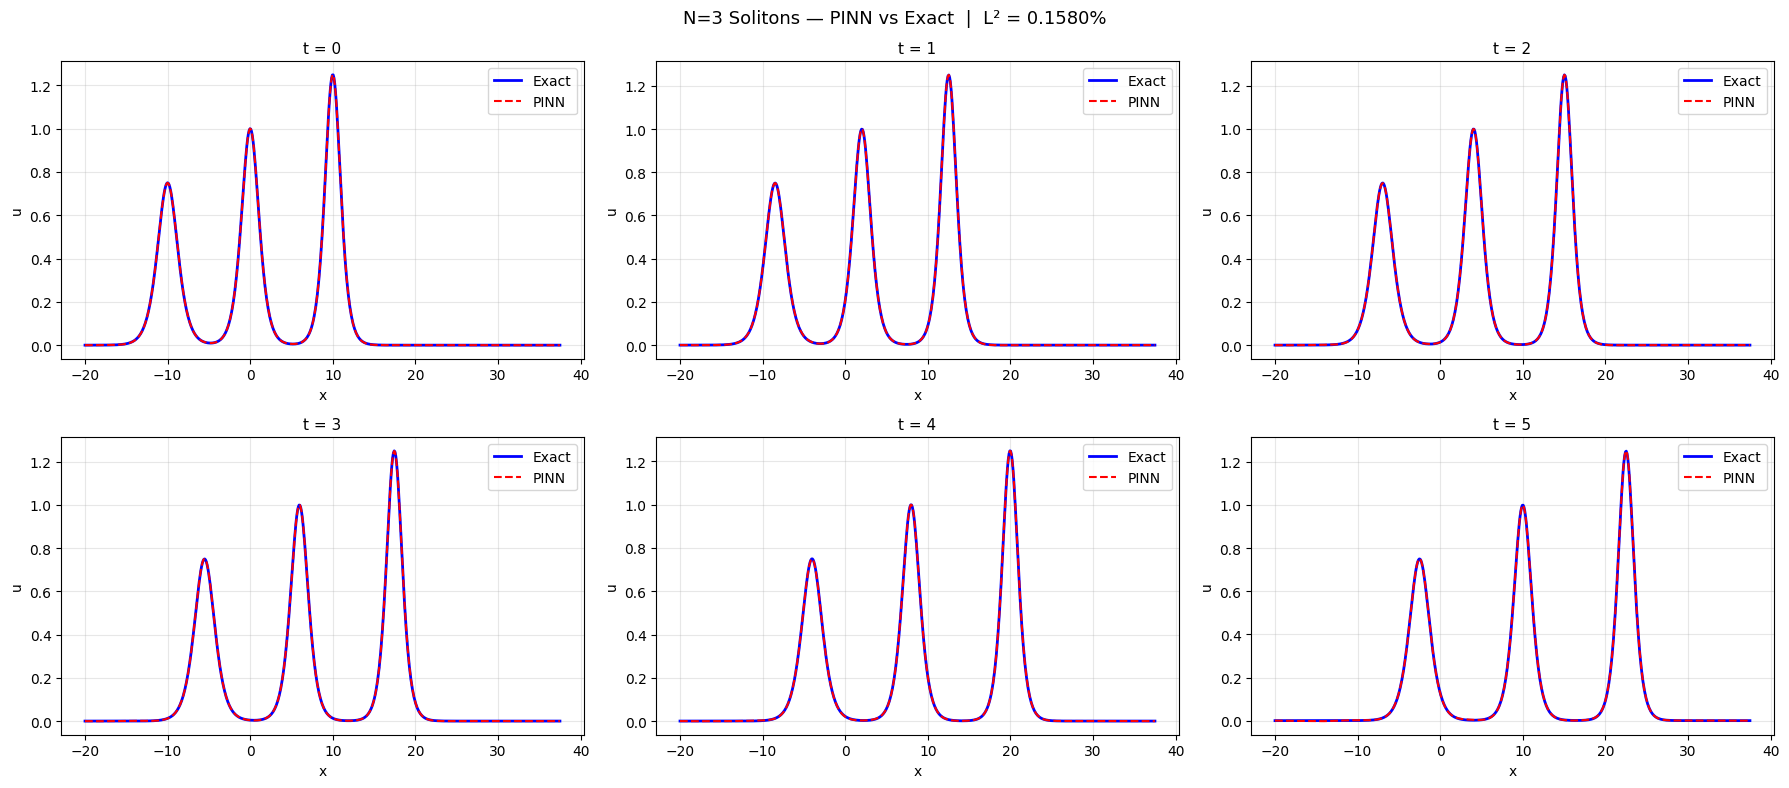

Saved: pinn_vs_exact_N3.png


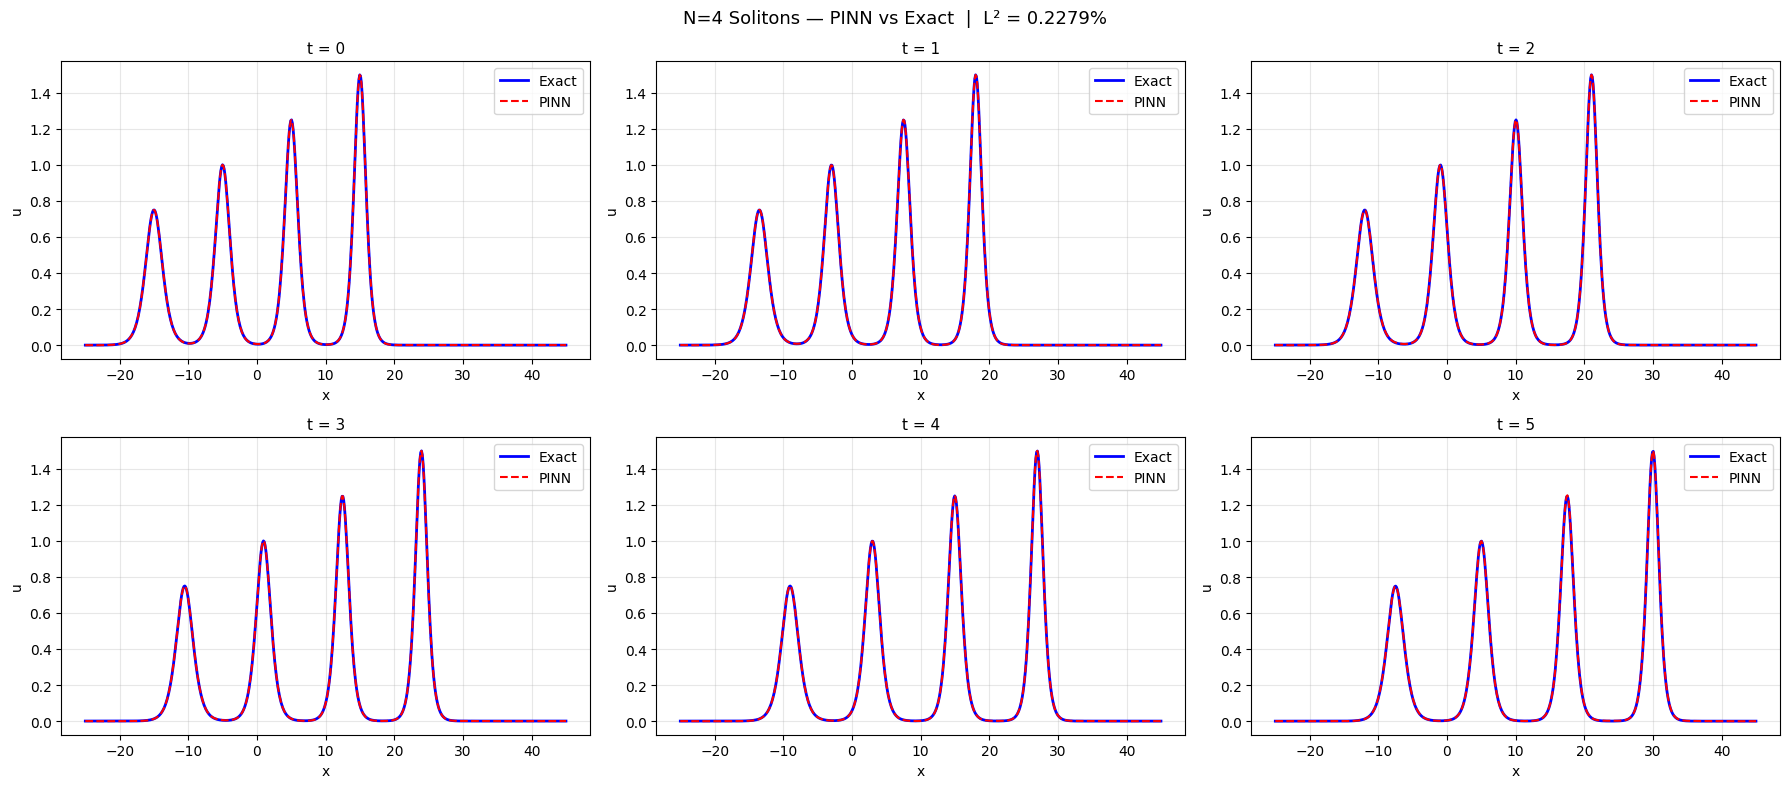

Saved: pinn_vs_exact_N4.png


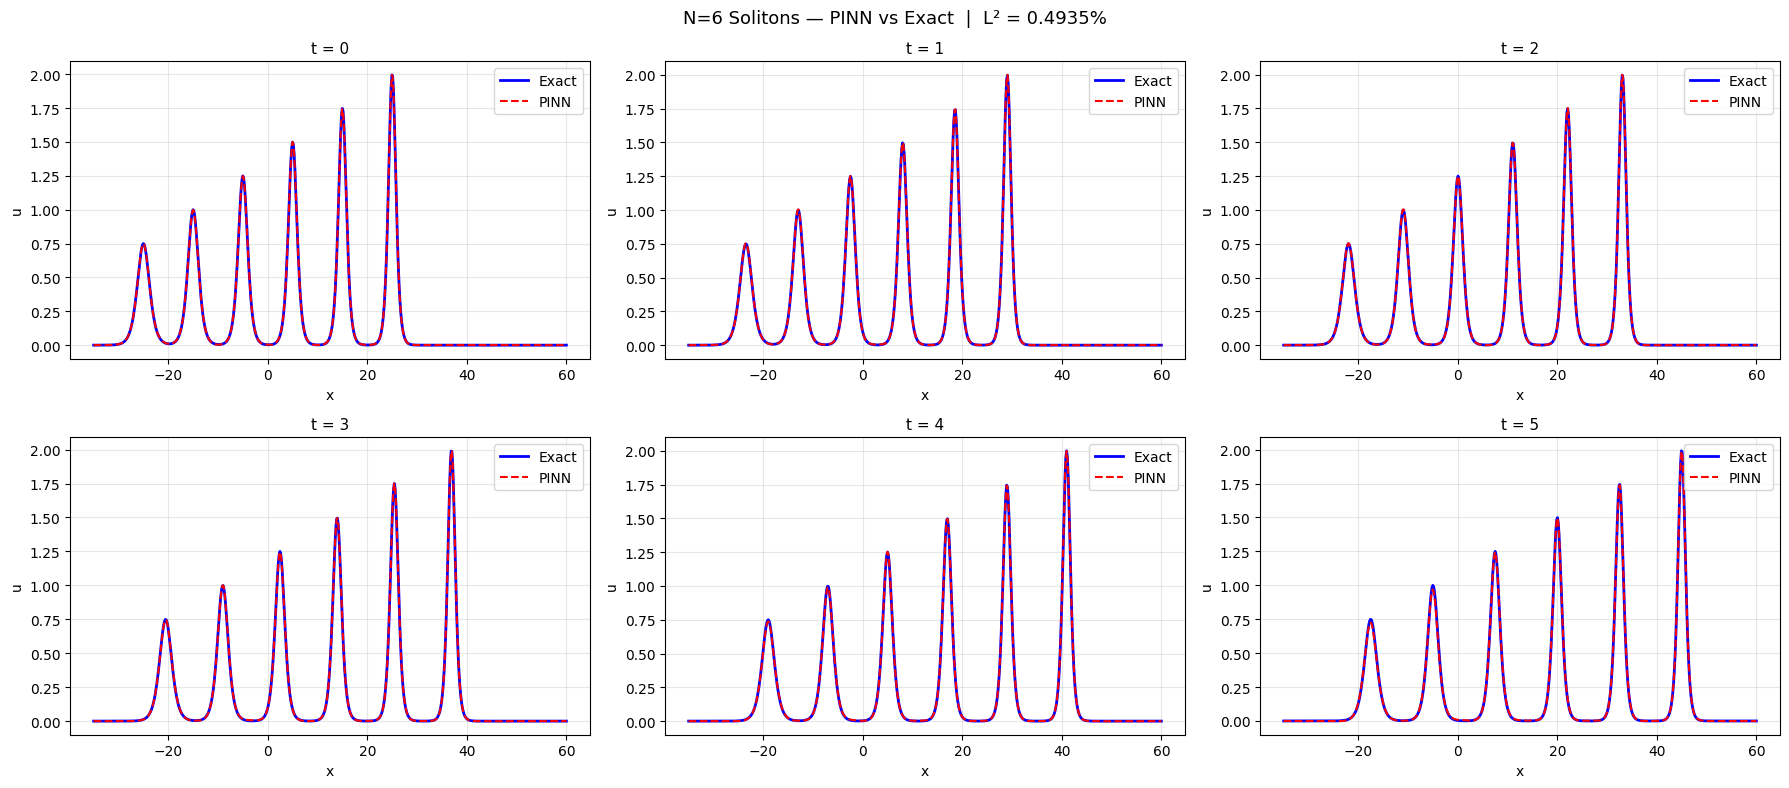

Saved: pinn_vs_exact_N6.png


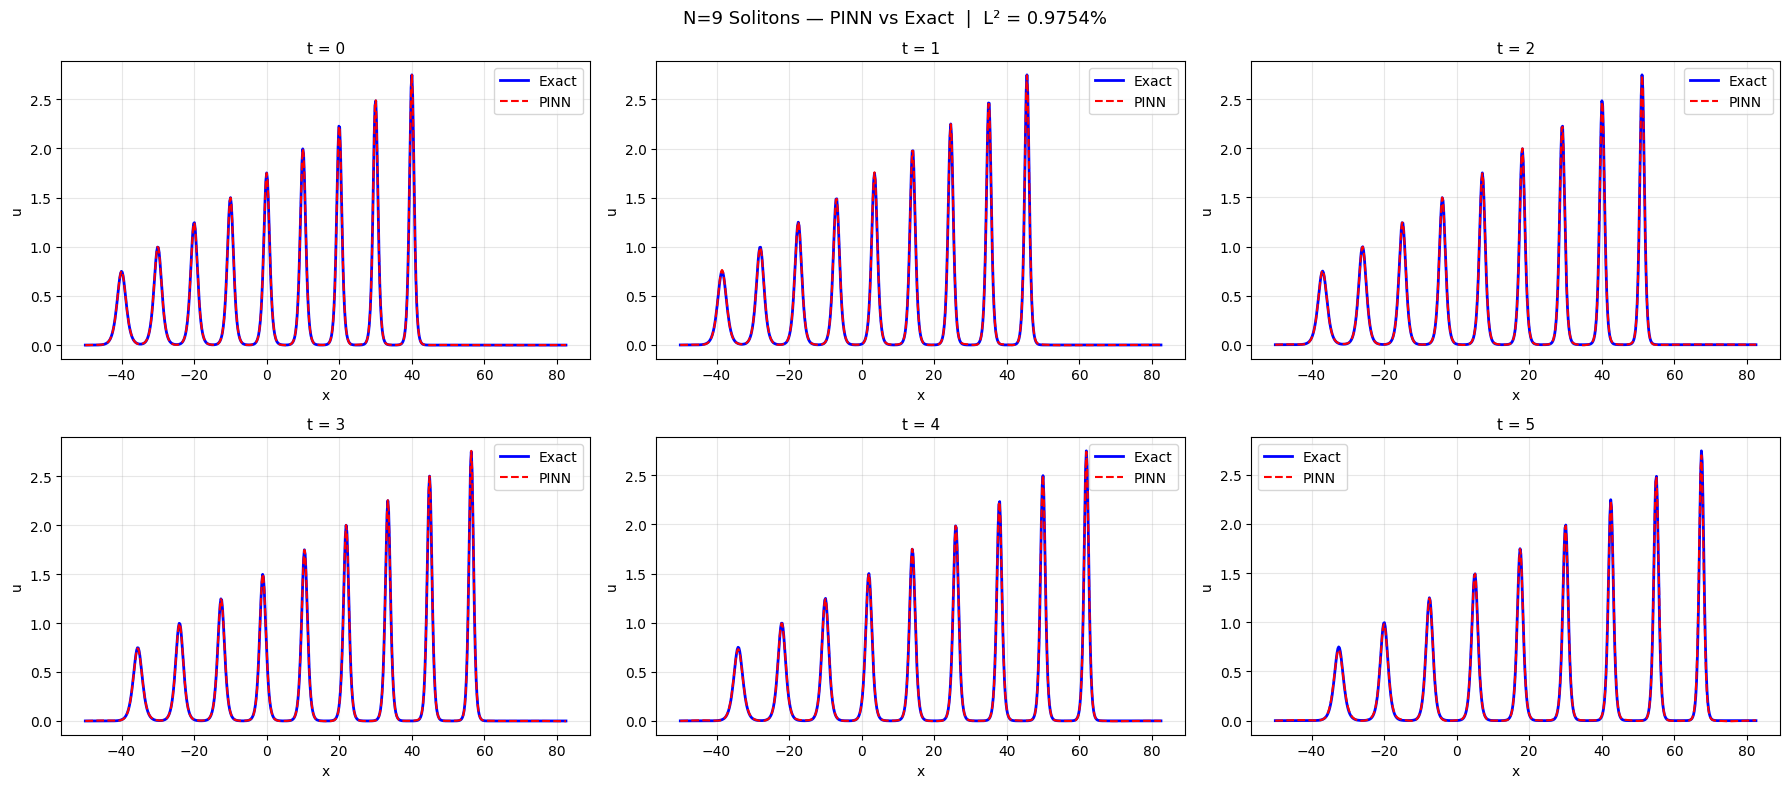

Saved: pinn_vs_exact_N9.png


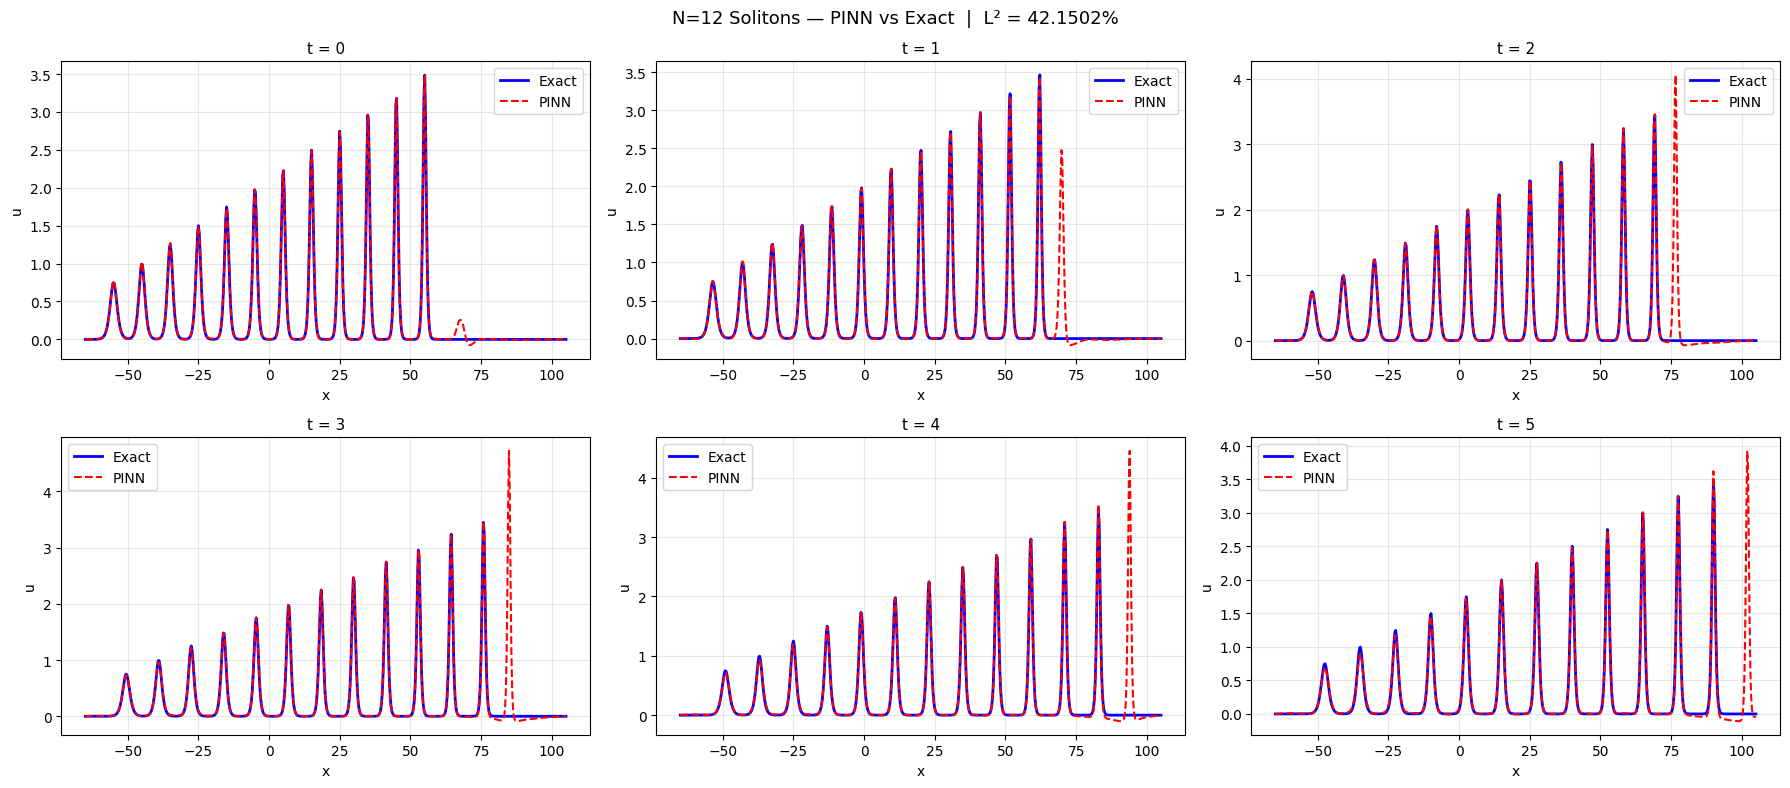

Saved: pinn_vs_exact_N12.png


In [12]:
for N in N_LIST:
    r = results[N]
    xl, xr = r['domain']
    x_p = torch.linspace(xl, xr, 600)
    t_p = torch.linspace(0, T_END, 100)
    X, TT = torch.meshgrid(x_p, t_p, indexing='ij')
    xf = X.reshape(-1, 1).to(device)
    tf = TT.reshape(-1, 1).to(device)

    with torch.no_grad():
        u_pred = r['model'](xf, tf).cpu().numpy().reshape(600, 100)
    u_exact = r['exact_fn'](X.reshape(-1), TT.reshape(-1)).numpy().reshape(600, 100)

    fig, axes = plt.subplots(2, 3, figsize=(18, 8))
    for idx, t_val in enumerate([0, 1, 2, 3, 4, 5]):
        ax  = axes[idx // 3][idx % 3]
        t_i = int(round(t_val * 99 / 5))
        ax.plot(x_p.numpy(), u_exact[:, t_i], 'b-',  label='Exact', linewidth=2.0)
        ax.plot(x_p.numpy(), u_pred[:,  t_i], 'r--', label='PINN',  linewidth=1.5)
        ax.set_title(f't = {t_val}', fontsize=11)
        ax.set_xlabel('x'); ax.set_ylabel('u')
        ax.legend(); ax.grid(True, alpha=0.3)

    fig.suptitle(
        f'N={N} Solitons — PINN vs Exact  |  L² = {r["l2_final"]*100:.4f}%',
        fontsize=13
    )
    plt.tight_layout()
    fname = f'pinn_vs_exact_N{N}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')


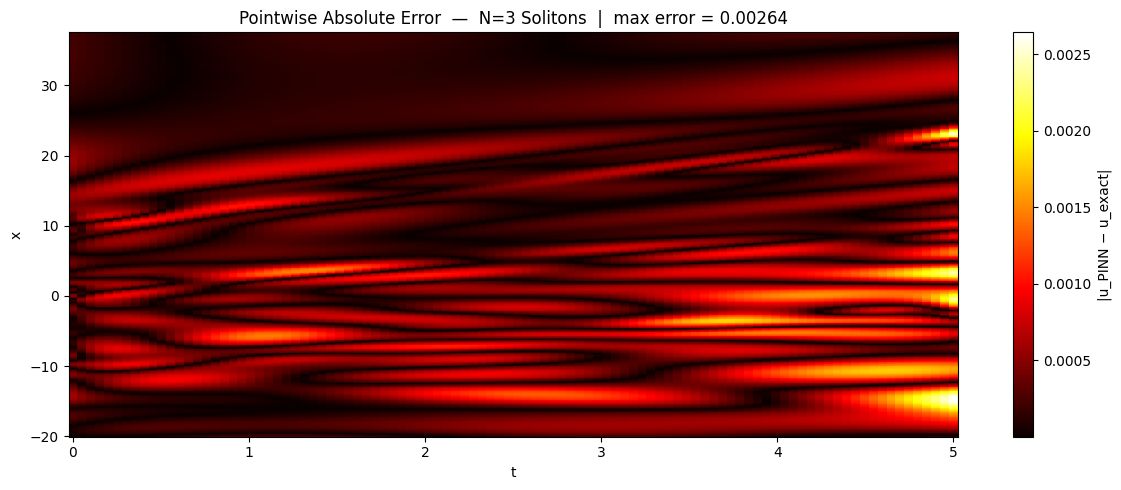

Saved: error_heatmap_N3.png


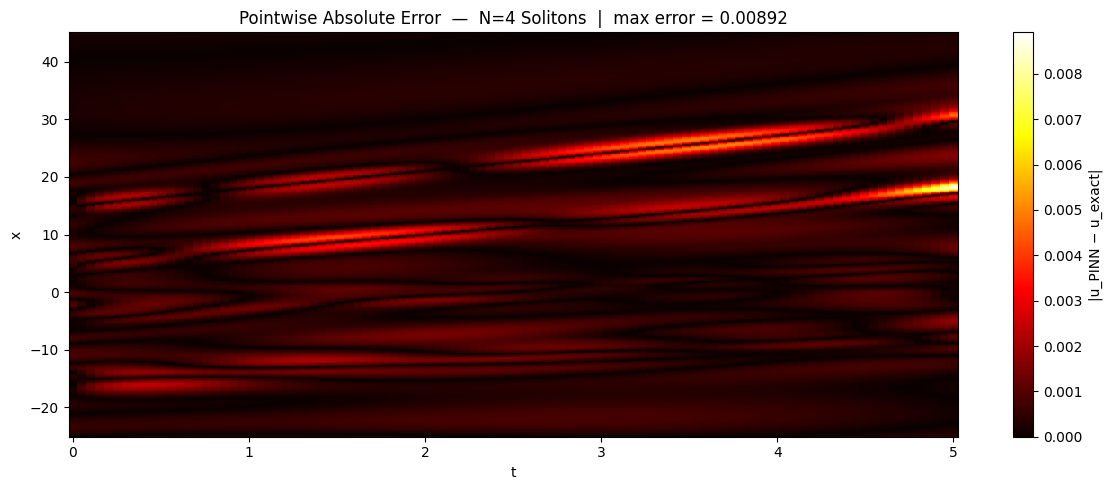

Saved: error_heatmap_N4.png


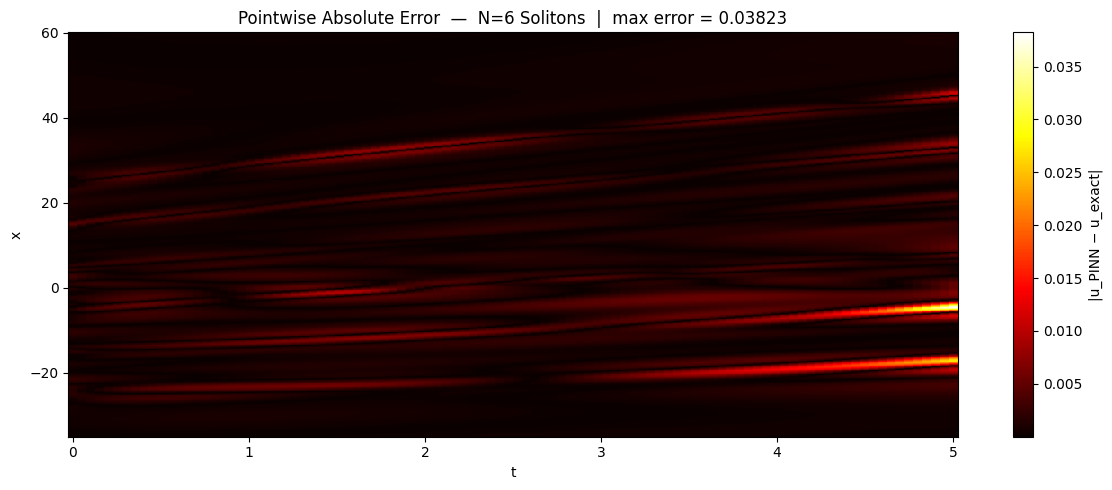

Saved: error_heatmap_N6.png


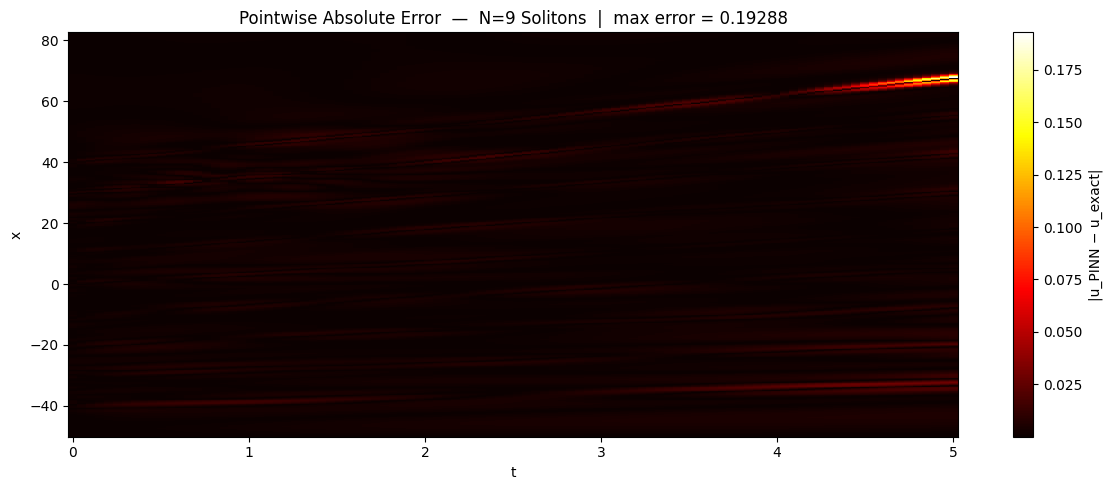

Saved: error_heatmap_N9.png


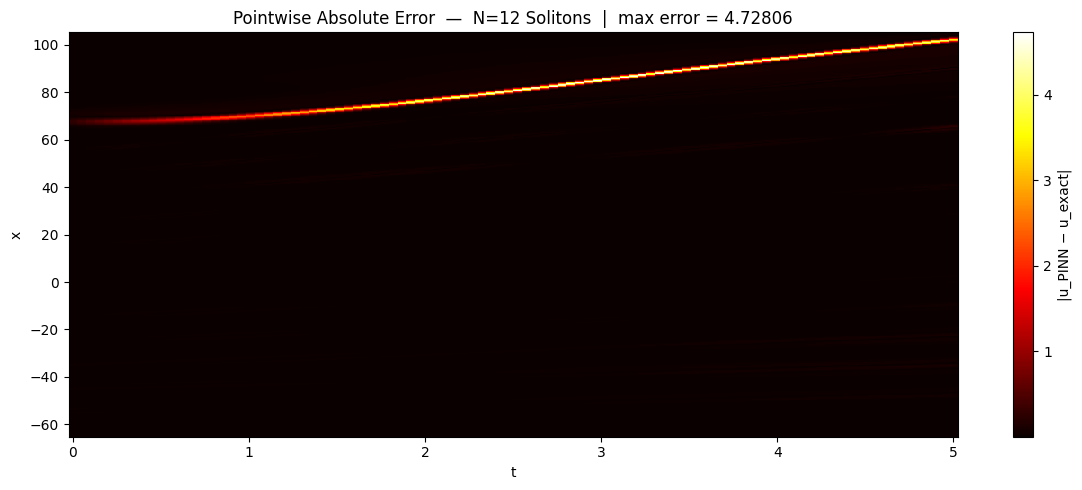

Saved: error_heatmap_N12.png


In [13]:
for N in N_LIST:
    r = results[N]
    xl, xr = r['domain']
    x_p = torch.linspace(xl, xr, 500)
    t_p = torch.linspace(0, T_END, 100)
    X, TT = torch.meshgrid(x_p, t_p, indexing='ij')
    xf = X.reshape(-1, 1).to(device)
    tf = TT.reshape(-1, 1).to(device)

    with torch.no_grad():
        u_pred = r['model'](xf, tf).cpu().numpy().reshape(500, 100)
    u_exact = r['exact_fn'](X.reshape(-1), TT.reshape(-1)).numpy().reshape(500, 100)

    error = np.abs(u_pred - u_exact)
    fig, ax = plt.subplots(figsize=(12, 5))
    im = ax.pcolormesh(t_p.numpy(), x_p.numpy(), error, cmap='hot', shading='auto')
    plt.colorbar(im, ax=ax, label='|u_PINN − u_exact|')
    ax.set_xlabel('t'); ax.set_ylabel('x')
    ax.set_title(
        f'Pointwise Absolute Error  —  N={N} Solitons  |  max error = {error.max():.5f}',
        fontsize=12
    )
    plt.tight_layout()
    fname = f'error_heatmap_N{N}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')


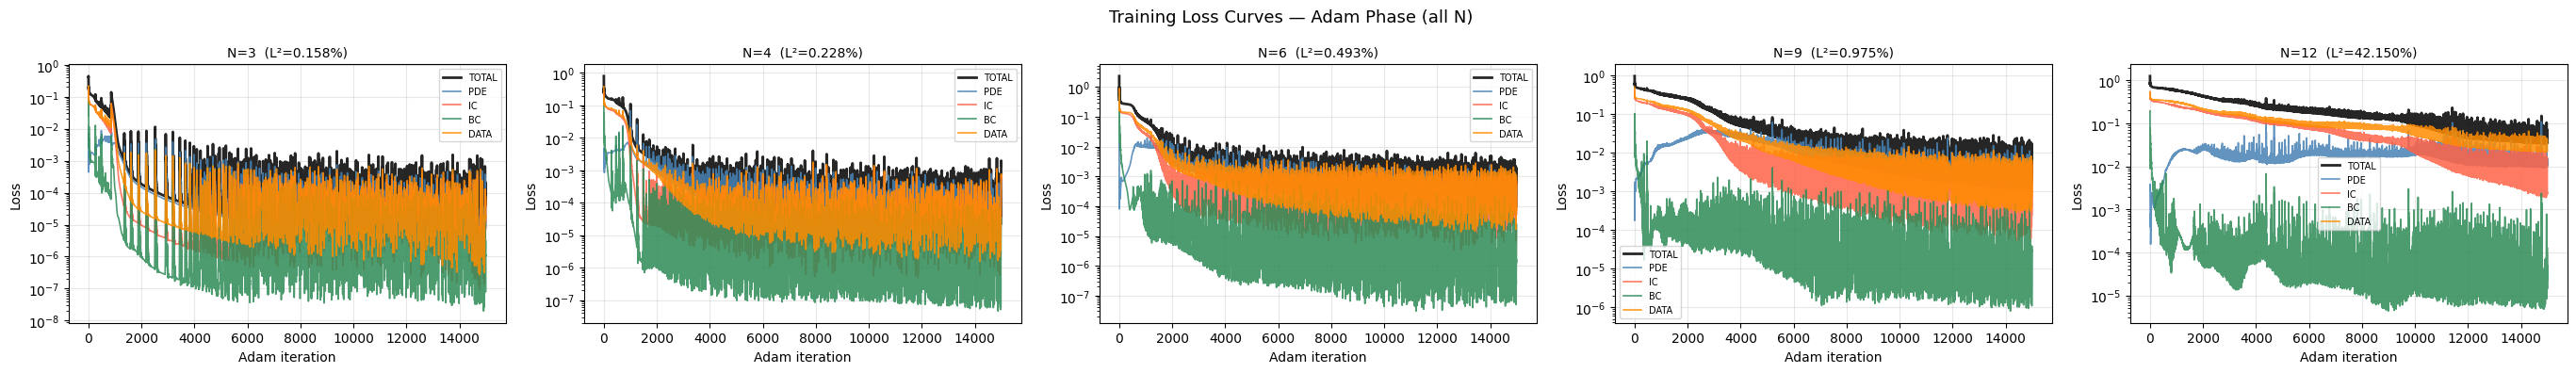

Saved: loss_curves_all_N.png


In [14]:
colours = {'total':'black','pde':'steelblue','ic':'tomato','bc':'seagreen','data':'darkorange'}

fig, axes = plt.subplots(1, len(N_LIST), figsize=(5.5 * len(N_LIST), 4), sharey=False)

for col, N in enumerate(N_LIST):
    ax   = axes[col]
    hist = results[N]['hist']
    for key, colour in colours.items():
        lw = 2.0 if key == 'total' else 1.2
        ax.semilogy(hist[key], label=key.upper(), color=colour, linewidth=lw, alpha=0.85)
    ax.set_title(f'N={N}  (L²={results[N]["l2_final"]*100:.3f}%)', fontsize=10)
    ax.set_xlabel('Adam iteration'); ax.set_ylabel('Loss')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle('Training Loss Curves — Adam Phase (all N)', fontsize=13)
plt.tight_layout()
plt.savefig('loss_curves_all_N.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: loss_curves_all_N.png')


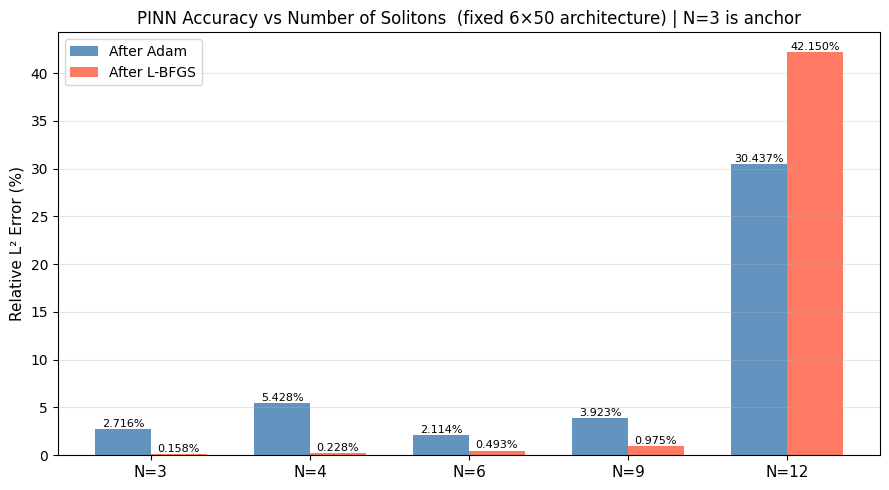

Saved: l2_summary.png


In [15]:
N_vals      = list(results.keys())
l2_adam_pct = [results[N]['l2_adam']  * 100 for N in N_vals]
l2_fin_pct  = [results[N]['l2_final'] * 100 for N in N_vals]

x_pos = np.arange(len(N_vals))
w     = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x_pos - w/2, l2_adam_pct, w, label='After Adam',   color='steelblue', alpha=0.85)
b2 = ax.bar(x_pos + w/2, l2_fin_pct,  w, label='After L-BFGS', color='tomato',    alpha=0.85)

for bar, val in zip(list(b1)+list(b2), l2_adam_pct+l2_fin_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}%', ha='center', va='bottom', fontsize=8)

# N=3 is now part of the bars (leftmost) — serves as the anchor point directly

ax.set_xticks(x_pos)
ax.set_xticklabels([f'N={N}' for N in N_vals], fontsize=11)
ax.set_ylabel('Relative L² Error (%)', fontsize=11)
ax.set_title('PINN Accuracy vs Number of Solitons  (fixed 6×50 architecture) | N=3 is anchor', fontsize=12)
ax.legend(fontsize=10); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('l2_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: l2_summary.png')


In [16]:
print('\n' + '='*72)
print(f"{'N':>4} | {'Speed range':>14} | {'Domain':>15} | {'L2 Adam':>10} | {'L2 Final':>10}")
print('-'*72)
for N in N_vals:
    r  = results[N]
    sp = r['speeds']
    cr = f'{sp[-1]:.1f} – {sp[0]:.1f}'
    xl, xr = r['domain']
    dom = f'[{xl:.0f}, {xr:.0f}]'
    anchor = '  <- anchor' if N == 3 else ''
    print(f"{N:>4} | {cr:>14} | {dom:>15} | {r['l2_adam']*100:>9.4f}% | {r['l2_final']*100:>9.4f}%{anchor}")
print('='*72)
print('\nN=3 anchor: expected L2 Final ≈ 0.18% (Pujari & Agarwal 2026 preliminary result).')
print('Deviation from 0.18% at N=3 indicates run-to-run variance (seed fixed at 99).')



   N |    Speed range |          Domain |    L2 Adam |   L2 Final
------------------------------------------------------------------------
   3 |      1.5 – 2.5 |       [-20, 38] |    2.7163% |    0.1580%  <- anchor
   4 |      1.5 – 3.0 |       [-25, 45] |    5.4282% |    0.2279%
   6 |      1.5 – 4.0 |       [-35, 60] |    2.1138% |    0.4935%
   9 |      1.5 – 5.5 |       [-50, 82] |    3.9235% |    0.9754%
  12 |      1.5 – 7.0 |      [-65, 105] |   30.4374% |   42.1502%

N=3 anchor: expected L2 Final ≈ 0.18% (Pujari & Agarwal 2026 preliminary result).
Deviation from 0.18% at N=3 indicates run-to-run variance (seed fixed at 99).
